### 흡연여부데이터 분석하기
최근 여러 기관에서는 흡연이 개인의 건강에 미치는 영향을 정확히 파악하고,
이를 기반으로 예방 중심의 건강관리 정책을 수립하려는 노력을 강화하고 있습니다.

하지만 “흡연 여부”를 직접 조사하는 것은 현실적으로 쉽지 않습니다.
이에 따라, 건강검진 데이터를 통해 흡연 여부를 데이터 기반으로 추정하고,
흡연자와 비흡연자 간의 생체·건강 지표 차이를 검증하려는 프로젝트가 시작되었습니다.

여러분은 이 프로젝트의 데이터 분석가이자 AI 엔지니어로 참여하게 되었습니다.
주어진 데이터에는 개인의 건강검진 결과(혈압, 혈당, 콜레스테롤, BMI 등)와
흡연 여부(label = 0 또는 1)가 포함되어 있습니다.

이제 여러분의 역할은 흡연 여부 데이터의 특성을 분석하고 시각화하며,
통계적 검정을 통해 변수 간 관계를 규명하는 것입니다.
시작해봅시다 !

#### 🎯 프로젝트 목표

	•	흡연자와 비흡연자 간의 건강 지표 차이 분석
	•	주요 변수들의 분포, 상관관계, 통계적 유의성 검증
	•	시각화를 통한 데이터 인사이트 도출
	•	추후 흡연 여부 예측 모델 개발을 위한 기초 분석 기반 마련




---



### 1. 가설 수립

In [1]:
# 가설1. 흡연의 여부는 헤모글로빈의 증가를 야기시킨다.
# 가설2. 흡연의 여부는 중성지방의 증가를 야기시킨다
# 가설3. 흡연의 여부는 고밀도지단백 감소를 야기시킨다

## 2. 데이터 로딩 및 전처리

In [2]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

mpl.rcParams['font.family'] = 'AppleGothic'
mpl.rcParams['axes.unicode_minus'] = False

health_data = pd.read_csv('smoking_health_data.csv')
health_data.head()

,ID,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label
0,TRAIN_0000,35,170,70,24.22,1.10,1,98.0,40.0,80.0,1.3,211,75,120,15.9,1,1.53,1
1,TRAIN_0001,40,150,55,24.44,1.00,0,173.0,39.0,104.0,0.6,251,46,184,11.8,1,1.45,0
2,TRAIN_0002,60,170,50,17.30,0.75,0,96.0,40.0,61.0,0.8,144,43,89,15.3,1,1.04,0
3,TRAIN_0003,40,150,45,20.00,0.50,0,92.0,40.0,46.0,0.7,178,66,110,13.4,1,1.18,0
4,TRAIN_0004,55,155,65,27.06,NaN,0,87.0,42.0,95.0,0.9,232,62,151,13.8,1,1.32,0


In [3]:
health_data.describe()

,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label
count,7000.000000,7000.000000,7000.000000,7000.000000,6860.000000,7000.000000,6860.000000,6860.000000,6860.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,43.973571,164.781429,65.932857,24.144423,1.011414,0.227429,99.307289,45.555102,127.028134,0.884900,197.276571,57.355429,115.346857,14.631914,1.083857,1.144696,0.367286
std,12.063793,9.170213,12.978702,3.501945,0.430137,0.419202,21.190058,8.831564,73.219161,0.241523,36.306494,14.506945,41.788153,1.540907,0.392051,0.432735,0.482100
min,20.000000,135.000000,30.000000,14.270000,0.100000,0.000000,57.000000,14.000000,21.000000,0.100000,86.000000,18.000000,1.000000,4.900000,1.000000,0.140000,0.000000
25%,35.000000,160.000000,55.000000,21.600000,0.800000,0.000000,89.000000,40.000000,74.000000,0.800000,173.000000,47.000000,92.000000,13.600000,1.000000,0.840000,0.000000
50%,40.000000,165.000000,65.000000,23.880000,1.000000,0.000000,96.000000,45.000000,107.000000,0.900000,195.000000,55.000000,113.000000,14.800000,1.000000,1.100000,0.000000
75%,50.000000,170.000000,75.000000,26.120000,1.200000,0.000000,104.000000,50.000000,161.000000,1.000000,219.000000,66.000000,136.000000,15.700000,1.000000,1.380000,1.000000
max,85.000000,190.000000,130.000000,42.450000,9.900000,1.000000,386.000000,91.000000,399.000000,10.000000,395.000000,157.000000,1340.000000,20.900000,5.000000,5.670000,1.000000


In [4]:
health_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ID        7000 non-null   object 
 1   나이        7000 non-null   int64  
 2   키(cm)     7000 non-null   int64  
 3   몸무게(kg)   7000 non-null   int64  
 4   BMI       7000 non-null   float64
 5   시력        6860 non-null   float64
 6   충치        7000 non-null   int64  
 7   공복 혈당     6860 non-null   float64
 8   혈압        6860 non-null   float64
 9   중성 지방     6860 non-null   float64
 10  혈청 크레아티닌  7000 non-null   float64
 11  콜레스테롤     7000 non-null   int64  
 12  고밀도지단백    7000 non-null   int64  
 13  저밀도지단백    7000 non-null   int64  
 14  헤모글로빈     7000 non-null   float64
 15  요 단백      7000 non-null   int64  
 16  간 효소율     7000 non-null   float64
 17  label     7000 non-null   int64  
dtypes: float64(8), int64(9), object(1)
memory usage: 984.5+ KB


In [5]:
# 결측치 확인
na_count = health_data.isna().sum().sort_values(ascending=False)
na_ratio = (health_data.isna().mean().sort_values(ascending=False) * 100).round(2)
pd.concat([na_count, na_ratio], keys=['na_count', 'na_ratio'], axis=1)

,na_count,na_ratio
중성 지방,140,2.0
시력,140,2.0
공복 혈당,140,2.0
혈압,140,2.0
콜레스테롤,0,0.0
간 효소율,0,0.0
요 단백,0,0.0
헤모글로빈,0,0.0
저밀도지단백,0,0.0
고밀도지단백,0,0.0


In [6]:
# BMI 기준
health_data['Weight_Status'] = pd.cut(health_data['BMI'], 
                                 bins=[0, 18.5, 25, 30, 50], 
                                 labels=['저체중', '정상', '과체중', '비만'])
# 나이 기준
health_data['Age_Group'] = pd.cut(health_data['나이'], 
                           bins=[0, 30, 50, 70, 100], 
                           labels=['~30s', '30~50s', '50~70s', '70s~'])

In [7]:
# 시력은 이산적인 값이라고 생각해서 최빈값
# 나머지는 연속형 변수라 이상치에 덜 민감한 중앙값으로 대체
sight_mode = health_data['시력'].mode()[0]
bsempt_mean = health_data['공복 혈당'].median(numeric_only=True)
bp_median = health_data['혈압'].median(numeric_only=True)
ntrfts_mean = health_data.groupby('Age_Group', observed=True)['중성 지방'].transform('median')
fill_values = {
    '시력': sight_mode,
    '공복 혈당': bsempt_mean,
    '혈압': bp_median,
    '중성 지방': ntrfts_mean
}
health_data.fillna(value=fill_values, inplace=True)

## 2. 데이터 분석

In [8]:
from matplotlib.colors import LinearSegmentedColormap

# color 설정
custom_cmap = LinearSegmentedColormap.from_list("custom_sky_salmon", ["skyblue", "white", "salmon"])

In [9]:
# 모든 수치형 데이터의 상관계수 표
corr = health_data.select_dtypes(include=[np.number]).corr().round(3)
corr

,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label
나이,1.000,-0.480,-0.326,-0.071,-0.211,-0.121,0.171,0.165,0.016,-0.092,0.044,0.007,0.031,-0.275,0.046,0.184,-0.175
키(cm),-0.480,1.000,0.679,0.159,0.177,0.079,0.022,0.008,0.153,0.359,-0.069,-0.216,-0.032,0.532,-0.009,-0.270,0.395
몸무게(kg),-0.326,0.679,1.000,0.828,0.139,0.064,0.124,0.123,0.334,0.303,0.034,-0.374,0.046,0.497,0.013,-0.430,0.312
BMI,-0.071,0.159,0.828,1.000,0.054,0.027,0.151,0.164,0.337,0.142,0.093,-0.344,0.084,0.273,0.024,-0.376,0.126
시력,-0.211,0.177,0.139,0.054,1.000,0.030,-0.029,-0.031,0.044,0.062,-0.014,-0.035,-0.022,0.126,-0.022,-0.077,0.073
충치,-0.121,0.079,0.064,0.027,0.030,1.000,-0.011,0.007,0.034,0.026,0.016,-0.013,0.001,0.077,-0.007,-0.063,0.098
공복 혈당,0.171,0.022,0.124,0.151,-0.029,-0.011,1.000,0.089,0.216,0.036,0.003,-0.120,-0.004,0.113,0.124,-0.126,0.111
혈압,0.165,0.008,0.123,0.164,-0.031,0.007,0.089,1.000,0.082,0.015,-0.013,-0.048,-0.017,0.046,0.015,-0.049,0.019
중성 지방,0.016,0.153,0.334,0.337,0.044,0.034,0.216,0.082,1.000,0.107,0.234,-0.423,0.006,0.274,0.042,-0.288,0.245
혈청 크레아티닌,-0.092,0.359,0.303,0.142,0.062,0.026,0.036,0.015,0.107,1.000,-0.009,-0.171,0.030,0.340,0.065,-0.142,0.198


Text(0, 0.5, '상관계수')

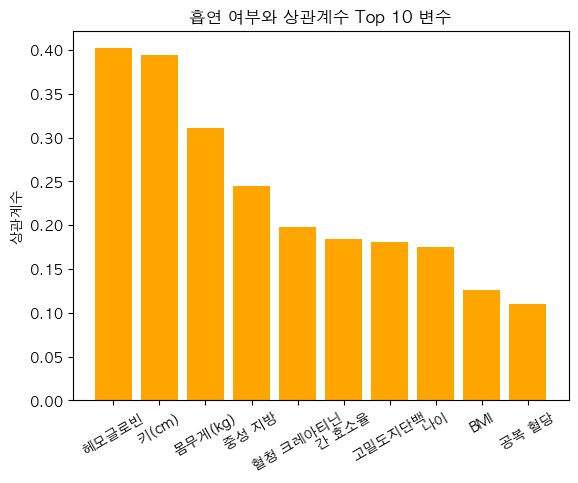

In [10]:
# 흡연 여부 상관관계 Top 10
num_data = health_data.select_dtypes(include=[np.number])
corr_label = num_data.corr()['label'].drop('label')
top10 = corr_label.abs().sort_values(ascending=False).head(10)

plt.bar(x= top10.index, height = top10.values,  color='orange')
plt.xticks(rotation=30)                                            
plt.title("흡연 여부와 상관계수 Top 10 변수")                                                  
plt.ylabel("상관계수")

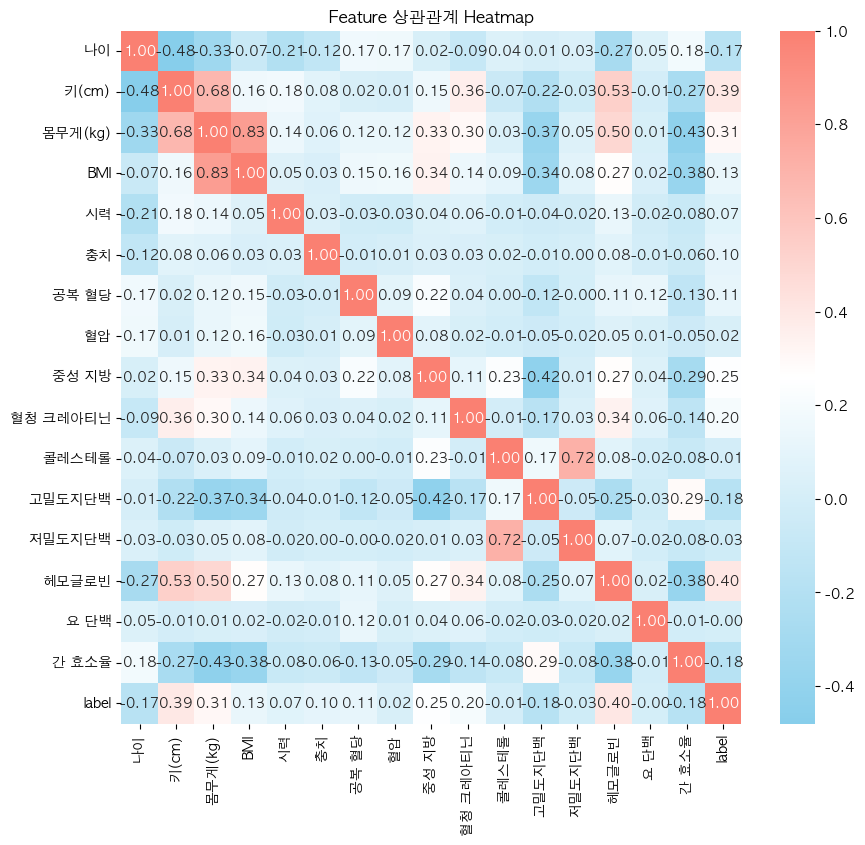

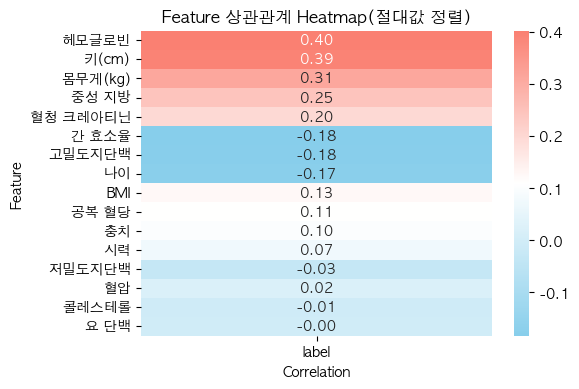

In [11]:
corr = health_data.corr(numeric_only=True)
plt.figure(figsize=(10,9))
sns.heatmap(corr, annot=True, fmt=".2f",  cmap=custom_cmap)
plt.title("Feature 상관관계 Heatmap")
plt.show()

# feature = [cols for cols in health_data.columns if cols not in ['키(cm)', '몸무게(kg)']]
feature = [cols for cols in health_data.columns]
corr = health_data[feature].corr(numeric_only=True)
label_corr = corr['label'].drop('label')
label_corr = label_corr.reindex(label_corr.abs().sort_values(ascending=False).index)

# 절대값 정렬 후 그래프 표시
plt.figure(figsize=(6, 4))
sns.heatmap(label_corr.to_frame(), annot=True, fmt='.2f',cmap=custom_cmap)
plt.title('Feature 상관관계 Heatmap(절대값 정렬)')
plt.ylabel("Feature")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

In [12]:
from scipy import stats

In [13]:
# 통계적 검정: 독립 표본 t-검정(헤모글로빈과 흡연)
group0 = health_data[health_data['label'] == 0]['헤모글로빈'].dropna()
group1 = health_data[health_data['label'] == 1]['헤모글로빈'].dropna()

#통계적 검정: 독립 표본 t-검정 (Welch's t-test, equal_var=False)
t_stat, p_val = stats.ttest_ind(group0, group1, equal_var=False)

print("\n--- Hemoglobin (헤모글로빈) 독립 표본 T-검정 결과 ---")
print(f"비흡연자 (Smoking_Label=0) 평균: {group0.mean():.4f}")
print(f"흡연자 (Smoking_Label=1) 평균: {group1.mean():.4f}")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")

if p_val < 0.05:
    print("\n결론: p-value가 0.05보다 작으므로, 흡연자와 비흡연자 간의 Hemoglobin 평균 차이는 통계적으로 유의미합니다.")
else:
    print("\n결론: p-value가 0.05보다 크므로, 통계적으로 유의미한 Hemoglobin 평균 차이가 있다고 보기 어렵습니다.")


--- Hemoglobin (헤모글로빈) 독립 표본 T-검정 결과 ---
비흡연자 (Smoking_Label=0) 평균: 14.1600
흡연자 (Smoking_Label=1) 평균: 15.4449
T-Statistic: -40.0224
P-value: 0.0000e+00

결론: p-value가 0.05보다 작으므로, 흡연자와 비흡연자 간의 Hemoglobin 평균 차이는 통계적으로 유의미합니다.


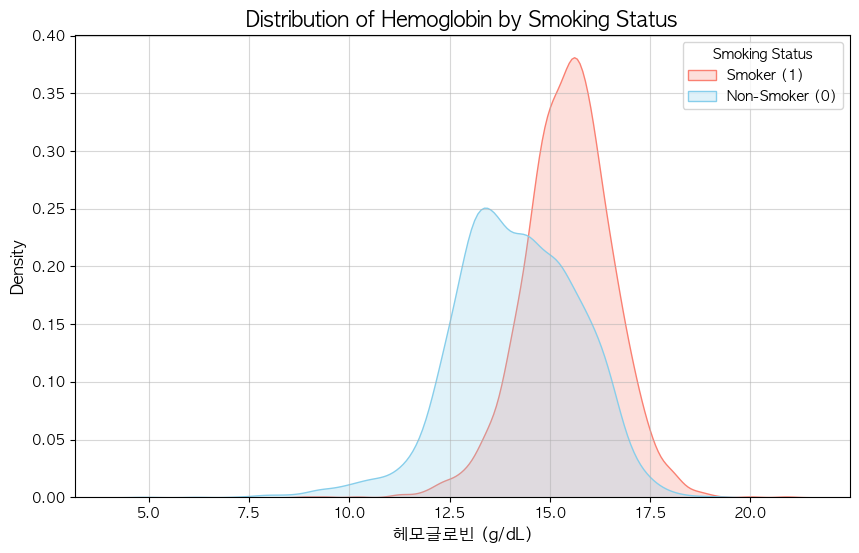

In [14]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
plt.figure(figsize=(10, 6))

# 헤모글로빈과 흡연과의 상관관계 분석
sns.kdeplot(data=health_data, x='헤모글로빈', hue='label', fill=True, common_norm=False, palette={0: 'skyblue', 1: 'salmon'})
plt.title('Distribution of Hemoglobin by Smoking Status', fontsize=15)
plt.xlabel('헤모글로빈 (g/dL)', fontsize=12) # 단위 g/dL 추가
plt.ylabel('Density', fontsize=12)
plt.legend(title='Smoking Status', labels=['Smoker (1)', 'Non-Smoker (0)'])
plt.grid(True, alpha=0.5)
plt.show()

In [15]:
# 통계적 검정: 독립 표본 t-검정
group0 = health_data[health_data['label'] == 0]['중성 지방'].dropna()
group1 = health_data[health_data['label'] == 1]['중성 지방'].dropna()

# Welch's t-test (equal_var=False): 분산이 같지 않을 때 더 견고함
t_stat, p_val = stats.ttest_ind(group0, group1, equal_var=False)

print("\n--- 중성 지방 (Triglycerides) 독립 표본 t-검정 결과 ---")
print(f"비흡연자 평균: {group0.mean():.2f}")
print(f"흡연자 평균: {group1.mean():.2f}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4e}") # 과학적 표기법으로 출력

if p_val < 0.05:
    print("\n결론: p-value가 0.05보다 작으므로, 흡연자와 비흡연자 간의 중성 지방 평균 차이는 통계적으로 유의미합니다.")
else:
    print("\n결론: p-value가 0.05보다 크므로, 통계적으로 유의미한 평균 차이가 있다고 보기 어렵습니다.")


--- 중성 지방 (Triglycerides) 독립 표본 t-검정 결과 ---
비흡연자 평균: 113.07
흡연자 평균: 149.97
t-statistic: -19.9715
p-value: 4.4331e-85

결론: p-value가 0.05보다 작으므로, 흡연자와 비흡연자 간의 중성 지방 평균 차이는 통계적으로 유의미합니다.


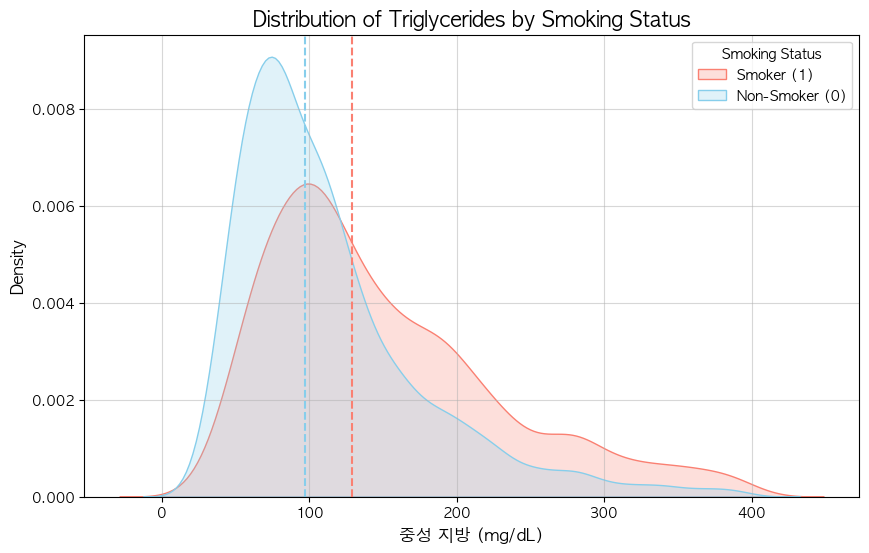

In [16]:
# 중성지방과 흡연과의 상관관계 분석
plt.figure(figsize=(10, 6))
sns.kdeplot(data=health_data, x='중성 지방', hue='label', fill=True, common_norm=False, palette={0: 'skyblue', 1: 'salmon'})
plt.title('Distribution of Triglycerides by Smoking Status', fontsize=15) # 제목 변경
plt.xlabel('중성 지방 (mg/dL)', fontsize=12) # x축 레이블 변경 (단위 mg/dL 추가)
plt.ylabel('Density', fontsize=12) # y축 레이블 변경
plt.legend(title='Smoking Status', labels=['Smoker (1)', 'Non-Smoker (0)']) # 범례 변경
plt.axvline(health_data[health_data['label'] == 0]['중성 지방'].median(), color='skyblue', linestyle='--')
plt.axvline(health_data[health_data['label'] == 1]['중성 지방'].median(), color='salmon', linestyle='--')
plt.grid(True, alpha=0.5)
plt.show()

In [17]:
# 통계적 검정: 독립 표본 t-검정(흡연자와 비흡연자)
group_non_smoker = health_data[health_data['label'] == 0]['고밀도지단백'].dropna()
group_smoker = health_data[health_data['label'] == 1]['고밀도지단백'].dropna()

#통계적 검정: 독립 표본 t-검정 (Welch's t-test, equal_var=False)
t_stat, p_val = stats.ttest_ind(group_non_smoker, group_smoker, equal_var=False)

print("\n--- HDL (고밀도지단백) 독립 표본 T-검정 결과 ---")
print(f"비흡연자 (Smoking_Label=0) 평균: {group_non_smoker.mean():.4f}")
print(f"흡연자 (Smoking_Label=1) 평균: {group_smoker.mean():.4f}")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")

if p_val < 0.05:
    print("\n결론: p-value가 0.05보다 작으므로, 흡연자와 비흡연자 간의 HDL 평균 차이는 통계적으로 유의미합니다.")
else:
    print("\n결론: p-value가 0.05보다 크므로, 통계적으로 유의미한 HDL 평균 차이가 있다고 보기 어렵습니다.")


--- HDL (고밀도지단백) 독립 표본 T-검정 결과 ---
비흡연자 (Smoking_Label=0) 평균: 59.3540
흡연자 (Smoking_Label=1) 평균: 53.9125
T-Statistic: 15.7347
P-value: 1.1919e-54

결론: p-value가 0.05보다 작으므로, 흡연자와 비흡연자 간의 HDL 평균 차이는 통계적으로 유의미합니다.


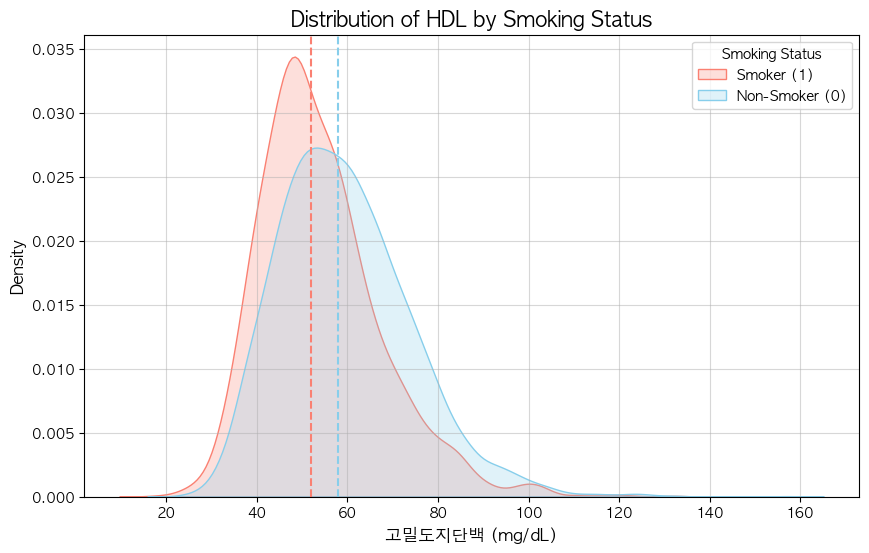

In [18]:
# 흡연자와 비흡연자의 상관관계 분석
plt.figure(figsize=(10, 6))
sns.kdeplot(data=health_data, x='고밀도지단백', hue='label', fill=True, common_norm=False, palette={0: 'skyblue', 1: 'salmon'})
plt.title('Distribution of HDL by Smoking Status', fontsize=15)
plt.xlabel('고밀도지단백 (mg/dL)', fontsize=12) # HDL unit mg/dL
plt.ylabel('Density', fontsize=12)
plt.legend(title='Smoking Status', labels=['Smoker (1)', 'Non-Smoker (0)'])
# Add median lines for visual comparison
plt.axvline(health_data[health_data['label'] == 0]['고밀도지단백'].median(), color='skyblue', linestyle='--', label='Non-Smoker Median')
plt.axvline(health_data[health_data['label'] == 1]['고밀도지단백'].median(), color='salmon', linestyle='--', label='Smoker Median')
plt.grid(True, alpha=0.5)
plt.show()

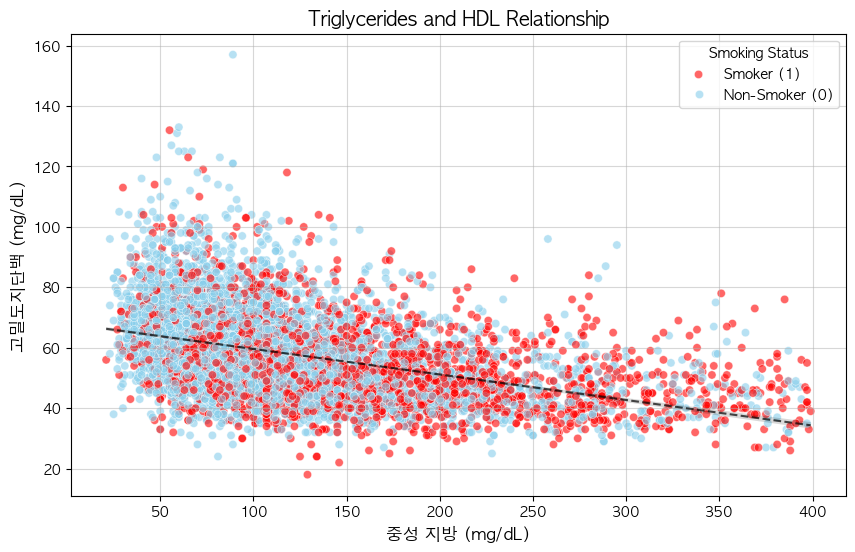

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=health_data, 
    x='중성 지방', 
    y='고밀도지단백', 
    hue='label', 
    palette={0: 'skyblue', 1: 'red'},
    alpha=0.6 # 데이터가 겹치는 것을 방지하기 위해 투명도 설정
)

# 전체 데이터에 대한 회귀선 추가 (음의 관계를 강조)
sns.regplot(
    data=health_data, 
    x='중성 지방', 
    y='고밀도지단백', 
    scatter=False,
    color='black', 
    line_kws={'linestyle': '--', 'alpha': 0.7, 'linewidth': 1.5}
)

plt.title('Triglycerides and HDL Relationship', fontsize=14)
plt.xlabel('중성 지방 (mg/dL)', fontsize=12)
plt.ylabel('고밀도지단백 (mg/dL)', fontsize=12)
plt.legend(title='Smoking Status', labels=['Smoker (1)', 'Non-Smoker (0)'])
plt.grid(True, alpha=0.5)
plt.show()

In [20]:
def spearman_corr_test(df, col1, col2):
    """DataFrame에서 두 컬럼 간의 스피어만 상관 계수(rho)와 p-value를 계산합니다."""
    # scipy.stats.spearmanr을 사용하여 rho와 p-value를 동시에 계산
    rho, p_value = stats.spearmanr(df[col1], df[col2], nan_policy='omit')
    return rho, p_value

# 4. 흡연 여부별 데이터 그룹 나누기
group_non_smoker = health_data[health_data['label'] == 0]
group_smoker = health_data[health_data['label'] == 1]

# 5. 그룹별 스피어만 상관 분석 수행
rho_overall, p_overall = spearman_corr_test(health_data, '중성 지방', '고밀도지단백')
rho_non_smoker, p_non_smoker = spearman_corr_test(group_non_smoker, '중성 지방', '고밀도지단백')
rho_smoker, p_smoker = spearman_corr_test(group_smoker, '중성 지방', '고밀도지단백')

# 6. 결과 출력
print("--- Triglycerides와 HDL 간의 스피어만 상관 분석 결과 ---")

print("\n[1] 전체 데이터셋")
print(f"상관 계수 (rho): {rho_overall:.4f}")
print(f"P-value: {p_overall:.4e}")

print("\n[2] 비흡연자 그룹 (Smoking_Label=0)")
print(f"상관 계수 (rho): {rho_non_smoker:.4f}")
print(f"P-value: {p_non_smoker:.4e}")

print("\n[3] 흡연자 그룹 (Smoking_Label=1)")
print(f"상관 계수 (rho): {rho_smoker:.4f}")
print(f"P-value: {p_smoker:.4e}")

--- Triglycerides와 HDL 간의 스피어만 상관 분석 결과 ---

[1] 전체 데이터셋
상관 계수 (rho): -0.4687
P-value: 0.0000e+00

[2] 비흡연자 그룹 (Smoking_Label=0)
상관 계수 (rho): -0.4577
P-value: 2.9262e-228

[3] 흡연자 그룹 (Smoking_Label=1)
상관 계수 (rho): -0.4024
P-value: 1.1038e-100


## 5. 결론 도출

In [ ]:
# 흡연자군의 분포가 비흡연자군에 비해 헤모글로빈 수치가 높다.
# 흡연자군의 분포가 비흡연자군보다 중성지방 수치가 높다.
# 흡연자군의 분포가 비흡연자군보다 고밀도지단백의 수치가 낮다.
# 중성지방과 고밀도지단백 수치는 반비례하며 흡연의 여부는 중성지방 상승과 고밀도지단백 감소에 기여한다.
# 분석결과, 흡연자 그룹은 헤모글로빈과 중성지방의 수치가 비흡연자 그룹에 비해 전반적으로 더 높은 경향을 보이며
#  , 반대로 고밀도지단백 수치는 더 낮은 경향을 확인할 수 있다.